<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
linear Regression -1
<a class="anchor" id="1"></a> 

In [1]:
# dataset upload
import pandas as pd
import numpy as np
df= pd.read_csv("../data/Students_Grading_Dataset.csv")

In [2]:
# display max  columns
pd.set_option('display.max_columns', None)
df.head(3)

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2


In [3]:
df.dtypes

Student_ID                     object
First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                          object
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object

In [4]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=False)

Parent_Education_Level        0.3588
Assignments_Avg               0.1034
Attendance (%)                0.1032
Email                         0.0000
Student_ID                    0.0000
First_Name                    0.0000
Last_Name                     0.0000
Department                    0.0000
Age                           0.0000
Gender                        0.0000
Midterm_Score                 0.0000
Quizzes_Avg                   0.0000
Participation_Score           0.0000
Projects_Score                0.0000
Final_Score                   0.0000
Total_Score                   0.0000
Grade                         0.0000
Extracurricular_Activities    0.0000
Study_Hours_per_Week          0.0000
Internet_Access_at_Home       0.0000
Family_Income_Level           0.0000
Stress_Level (1-10)           0.0000
Sleep_Hours_per_Night         0.0000
dtype: float64

In [5]:
df[df.isna().any(axis=1)].head() # no missing values

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
5,S1005,Liam,Brown,student5@university.com,Male,21,Engineering,NaN,78.85,43.53,71.40,52.20,6.38,67.29,62.08,B,8.5,Yes,Yes,PhD,High,1,5.0
6,S1006,Ahmed,Jones,student6@university.com,Male,24,Business,57.60,66.26,89.07,84.52,98.40,2.30,93.65,83.21,F,21.3,No,Yes,NaN,Low,5,6.4
7,S1007,Ahmed,Smith,student7@university.com,Male,19,Engineering,51.91,45.67,73.96,80.12,95.90,3.73,93.24,81.93,F,27.3,Yes,No,NaN,Medium,4,4.3
9,S1009,Sara,Smith,student9@university.com,Female,22,Engineering,64.01,87.96,98.47,96.98,55.63,5.88,78.60,84.99,A,9.6,No,Yes,NaN,Medium,10,6.4


In [6]:
df.dtypes

Student_ID                     object
First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                          object
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object

In [7]:
# look for missing values 
df.isna().sum()/df.shape[0]

Student_ID                    0.0000
First_Name                    0.0000
Last_Name                     0.0000
Email                         0.0000
Gender                        0.0000
Age                           0.0000
Department                    0.0000
Attendance (%)                0.1032
Midterm_Score                 0.0000
Final_Score                   0.0000
Assignments_Avg               0.1034
Quizzes_Avg                   0.0000
Participation_Score           0.0000
Projects_Score                0.0000
Total_Score                   0.0000
Grade                         0.0000
Study_Hours_per_Week          0.0000
Extracurricular_Activities    0.0000
Internet_Access_at_Home       0.0000
Parent_Education_Level        0.3588
Family_Income_Level           0.0000
Stress_Level (1-10)           0.0000
Sleep_Hours_per_Night         0.0000
dtype: float64

In [9]:
df.describe().T[["mean", "max"]]

,mean,max
Age,21.048400,24.00
Attendance (%),75.431409,100.00
Midterm_Score,70.326844,99.98
Final_Score,69.640788,99.98
Assignments_Avg,74.798673,99.98
Quizzes_Avg,74.910728,99.96
Participation_Score,4.980024,10.00
Projects_Score,74.924860,100.00
Total_Score,75.121804,99.99
Study_Hours_per_Week,17.658860,30.00


In [17]:
df.select_dtypes("O").describe().T

,count,unique,top,freq
Student_ID,5000,5000,S5999,1
First_Name,5000,8,Maria,657
Last_Name,5000,6,Johnson,868
Email,5000,5000,student4999@university.com,1
Gender,5000,2,Male,2551
Department,5000,4,CS,2022
Grade,5000,5,A,1495
Extracurricular_Activities,5000,2,No,3493
Internet_Access_at_Home,5000,2,Yes,4485
Parent_Education_Level,3206,4,PhD,820


In [18]:
df.Department.mode()[0] # get the most frequent value   

'CS'

In [19]:
# use simpel imputer to fill missing values with mean  value
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df["Final_Score"] = imputer.fit_transform(df[["Final_Score"]]) 
df["Attendance (%)"] = imputer.fit_transform(df[["Attendance (%)"]]) 


In [27]:
X = df[["Attendance (%)"]]
y = df['Final_Score']

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [30]:
lr.fit(X_train,y_train)

LinearRegression()

In [31]:
lr.intercept_, lr.coef_
# make predictions


(np.float64(72.6240888990697), array([-0.0385076]))

In [32]:
# make predictions
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)
# evaluate the model
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Train RMSE: 17.26794997439393
Test RMSE: 17.09037684404111


In [35]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))
print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred_test))


Train MAE: 14.969900908364169
Test MAE: 14.92102018172294
Train MAPE: 0.23689685220468068
Test MAPE: 0.23729411886047153


In [34]:
# evaluate the model
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))


Train R2: 0.0009255623303247029
Test R2: -0.0015733692410364597


In [37]:
# display ina dataframe , actual target values vs predicted values 
df_pred = pd.DataFrame({"Actual": y_test, "Predicted": y_pred_test})
df_pred["Difference"] = df_pred["Actual"] - df_pred["Predicted"]
df_pred.head(10)

,Actual,Predicted,Difference
1501,44.10,68.906565,-24.806565
2586,83.07,69.504588,13.565412
2653,81.60,68.791042,12.808958
1055,44.83,70.272045,-25.442045
705,82.38,69.167262,13.212738
106,71.22,70.338663,0.881337
589,42.24,69.980542,-27.740542
2468,47.55,69.380209,-21.830209
2413,62.94,69.772216,-6.832216
1600,77.64,70.478060,7.161940


In [38]:
df_pred["Difference"].describe().T[["mean", "max"]]

mean    -0.393092
max     30.804446
Name: Difference, dtype: float64

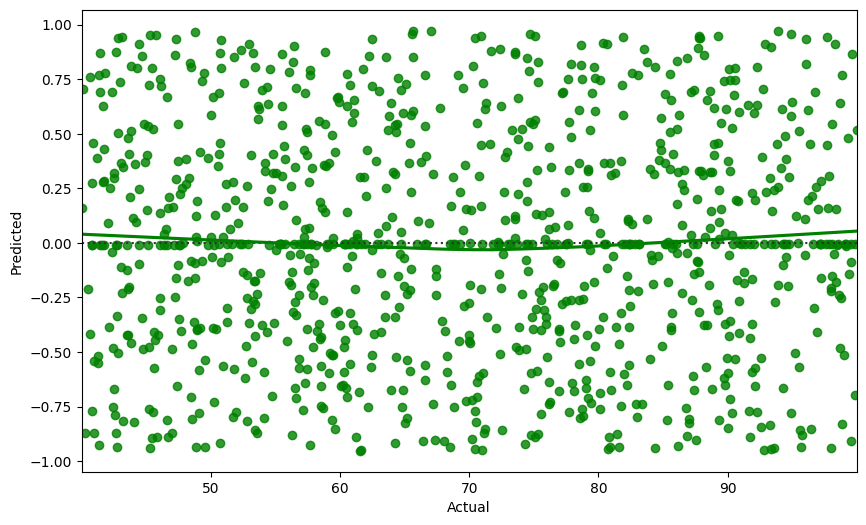

In [41]:
# use sbs rediplot to plot residual 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
_=sns.residplot(x=df_pred.Actual, y=df_pred.Predicted, lowess=True, color="g")
